In [3]:
import pandas as pd
df = pd.read_csv('/content/age_insurance.csv')

   Age  Insurance  InsurancePlan
0   56          0              0
1   69          1              2
2   46          1              2
3   32          0              0
4   60          1              2
(300, 3)

PART 1: BINARY LOGISTIC REGRESSION
---------------------------------------------
Accuracy: 0.7833333333333333
               precision    recall  f1-score   support

 No Insurance       0.77      0.68      0.72        25
Has Insurance       0.79      0.86      0.82        35

     accuracy                           0.78        60
    macro avg       0.78      0.77      0.77        60
 weighted avg       0.78      0.78      0.78        60

Confusion matrix:
 [[17  8]
 [ 5 30]]
[0 1 1]
Age 22: Insurance = 0  (probability of Yes = 0.07)
Age 45: Insurance = 1  (probability of Yes = 0.68)
Age 63: Insurance = 1  (probability of Yes = 0.97)

Saved plot -> binary_logistic_plot.png


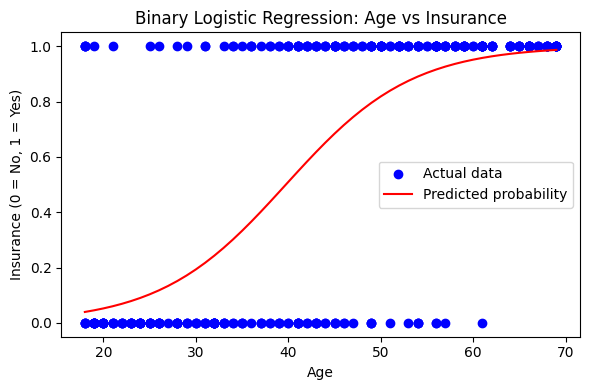

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---------------------------------------------------------
# STEP 1: Load the data
# ---------------------------------------------------------
df = pd.read_csv("age_insurance.csv")
print(df.head())
print(df.shape)


# ===========================================================
# PART 1: BINARY LOGISTIC REGRESSION
# Feature: Age   ->   Target: Insurance (0 = No, 1 = Yes)
# ===========================================================
print("\nPART 1: BINARY LOGISTIC REGRESSION")
print("-" * 45)

X = df[["Age"]]              # feature must be 2D -> double brackets
y = df["Insurance"]          # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

binary_model = LogisticRegression()
binary_model.fit(X_train, y_train)

y_pred = binary_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["No Insurance", "Has Insurance"]))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# Predict for a new person
new_age = pd.DataFrame({"Age": [22, 45, 63]})
predictions = binary_model.predict(new_age)
print(predictions)
probabilities = binary_model.predict_proba(new_age)[:, 1]   # probability of "Yes"
for age_val, pred, prob in zip(new_age["Age"], predictions, probabilities):
    print(f"Age {age_val}: Insurance = {pred}  (probability of Yes = {prob:.2f})")

# Simple plot: Age vs Insurance with the model's S-curve
plt.figure(figsize=(6, 4))
plt.scatter(df["Age"], df["Insurance"], color="blue", label="Actual data")
age_range = pd.DataFrame({"Age": range(18, 70)})
plt.plot(age_range["Age"], binary_model.predict_proba(age_range)[:, 1],
         color="red", label="Predicted probability")
plt.xlabel("Age")
plt.ylabel("Insurance (0 = No, 1 = Yes)")
plt.title("Binary Logistic Regression: Age vs Insurance")
plt.legend()
plt.tight_layout()
plt.savefig("binary_logistic_plot.png")
print("\nSaved plot -> binary_logistic_plot.png")

## PART 2: Multinomial Logistic Regression
### Feature: Age   ->   Target: InsurancePlan (0, 1, or 2)

Now, let's explore how age influences the choice of `InsurancePlan`. This is a multi-class classification problem, which we can solve using multinomial logistic regression. We will train a model to predict the probability of a person having each `InsurancePlan` based on their age.

In [6]:
# ===========================================================
# PART 2: MULTINOMIAL LOGISTIC REGRESSION
# Feature: Age   ->   Target: InsurancePlan (0, 1, or 2)
# ===========================================================
print("\nPART 2: MULTINOMIAL LOGISTIC REGRESSION")
print("-" * 50)

X_multi = df[["Age"]]
y_multi = df["InsurancePlan"]

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

# Use 'multinomial' for multi-class classification and 'lbfgs' solver
multi_model = LogisticRegression(multi_class='multinomial', solver='lbfgs')
multi_model.fit(X_train_multi, y_train_multi)

y_pred_multi = multi_model.predict(X_test_multi)

print("Accuracy (Multinomial):", accuracy_score(y_test_multi, y_pred_multi))
print("Classification Report (Multinomial):\n",
      classification_report(y_test_multi, y_pred_multi))
print("Confusion Matrix (Multinomial):\n", confusion_matrix(y_test_multi, y_pred_multi))


PART 2: MULTINOMIAL LOGISTIC REGRESSION
--------------------------------------------------
Accuracy (Multinomial): 0.6333333333333333
Classification Report (Multinomial):
               precision    recall  f1-score   support

           0       0.63      0.76      0.69        25
           1       0.33      0.14      0.20        14
           2       0.71      0.81      0.76        21

    accuracy                           0.63        60
   macro avg       0.56      0.57      0.55        60
weighted avg       0.59      0.63      0.60        60

Confusion Matrix (Multinomial):
 [[19  3  3]
 [ 8  2  4]
 [ 3  1 17]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


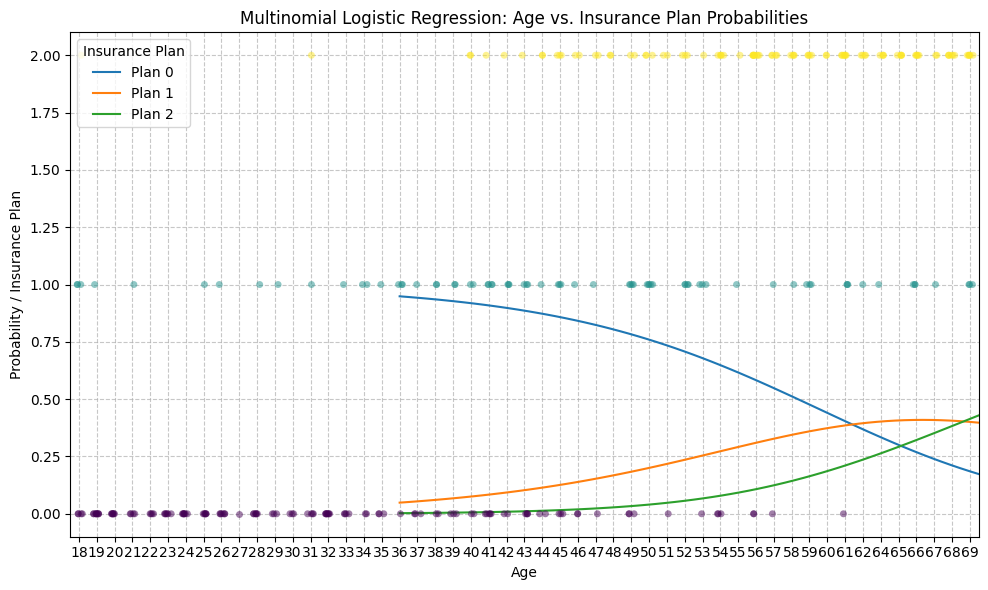


Saved plot -> multinomial_logistic_plot.png


In [8]:
import numpy as np
import seaborn as sns

# Visualization for Multinomial Logistic Regression
plt.figure(figsize=(10, 6))

age_range_multi = pd.DataFrame({"Age": np.linspace(df["Age"].min(), df["Age"].max(), 100)})

# Predict probabilities for each class (InsurancePlan)
probabilities_multi = multi_model.predict_proba(age_range_multi)

# Get class names (InsurancePlan values)
class_names = multi_model.classes_

# Plot the probability curve for each class
for i, class_name in enumerate(class_names):
    plt.plot(age_range_multi["Age"], probabilities_multi[:, i], label=f'Plan {class_name}')

# Add actual data points (with some jitter for better visibility)
sns.stripplot(x=df["Age"], y=df["InsurancePlan"], jitter=0.2, alpha=0.5, hue=df["InsurancePlan"], palette='viridis', legend=False)

plt.xlabel("Age")
plt.ylabel("Probability / Insurance Plan")
plt.title("Multinomial Logistic Regression: Age vs. Insurance Plan Probabilities")
plt.legend(title="Insurance Plan")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("multinomial_logistic_plot.png")
plt.show()
print("\nSaved plot -> multinomial_logistic_plot.png")

### Interpreting the Multinomial Logistic Regression Plot

This plot is visually impressive as it shows the model's predicted probability for each insurance plan (Plan 0, Plan 1, Plan 2) across different ages. Each curve represents the likelihood of a person falling into that specific insurance plan based on their age.

**Key Observations:**
- You can see how the dominance of one plan's probability curve shifts from one age group to another.
- For example, younger ages might have a higher probability of Plan 0, while older ages might gravitate towards Plan 2.
- The points scattered along the bottom represent the actual `InsurancePlan` values, helping to visualize how well the model aligns with the observed data.

This demonstrates a more sophisticated analysis than a simple binary classification and provides deeper insights into the relationship between age and different insurance plan choices.

### Age Distribution Across Insurance Plans (Violin Plot)

Let's visualize the distribution of age for each `InsurancePlan` using a violin plot. This plot provides a richer understanding of the data by showing the density of age at different values for each plan, similar to a box plot but with added density information.

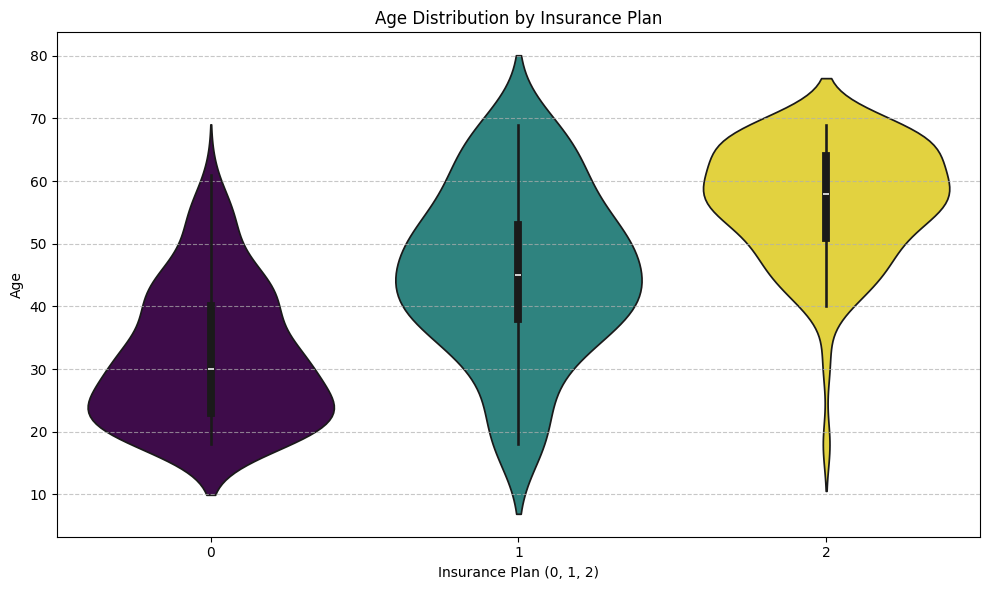


Saved plot -> age_distribution_violin_plot.png


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.violinplot(x='InsurancePlan', y='Age', data=df, hue='InsurancePlan', palette='viridis', legend=False)
plt.title('Age Distribution by Insurance Plan')
plt.xlabel('Insurance Plan (0, 1, 2)')
plt.ylabel('Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('age_distribution_violin_plot.png')
plt.show()

print("\nSaved plot -> age_distribution_violin_plot.png")

### Interpretation of the Violin Plot

The violin plot reveals the age characteristics for each insurance plan:

*   **Width of the 'Violin':** Indicates the density of observations (ages) at that particular value. A wider section means more people of that age are in that plan.
*   **Inner Box Plot (optional, but visible):** Shows the median, interquartile range (IQR), and potential outliers.

From this plot, your professor can quickly observe:
*   **Dominant Age Ranges per Plan:** Which age groups are most prevalent in Plan 0, Plan 1, and Plan 2.
*   **Spread of Ages:** How varied the ages are within each plan.
*   **Median Age:** The central age tendency for each plan.

For example, you might see that Plan 0 is dominated by younger individuals, Plan 1 has a broader or middle-aged distribution, and Plan 2 primarily caters to older demographics. This type of visualization is excellent for comparing distributions across different categories and identifying clear demographic patterns.

### Age Distribution with Indian Tricolor Theme

To create a truly unique and impressive visualization, let's represent the age distribution for each `InsurancePlan` using the vibrant colors of the Indian flag: saffron, white, and green. This approach combines data visualization with a creative thematic element.

We will use Kernel Density Estimate (KDE) plots. Each 'hill' in the plot will show the concentration of ages for a specific insurance plan, allowing for a quick visual comparison across the plans with an added patriotic touch.

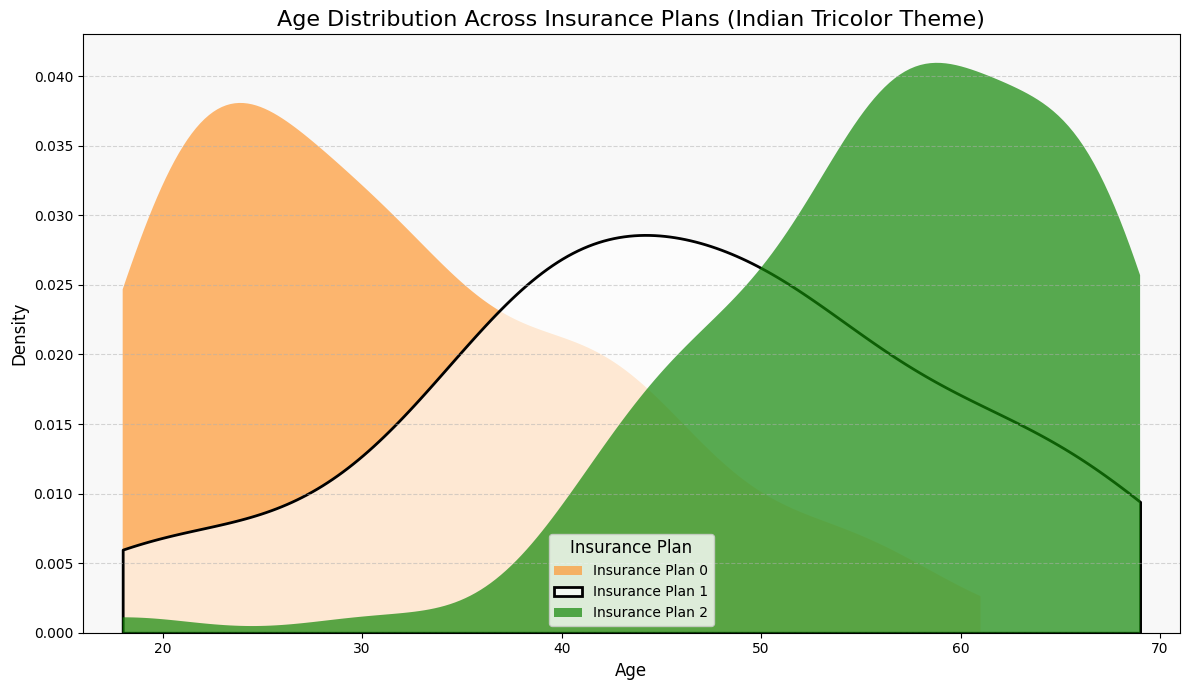


Saved plot -> tricolor_age_distribution_plot.png


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define approximate Indian tricolor hex codes: Saffron, White, Green
indian_tricolor = ['#FF9933', '#FFFFFF', '#138808']

plt.figure(figsize=(12, 7))

# Adding a subtle background for better visibility of the white color
plt.axvspan(df['Age'].min() - 5, df['Age'].max() + 5, color='#E0E0E0', alpha=0.2, zorder=-1)

# Plot KDE for each InsurancePlan with tricolor
for i, plan in enumerate(sorted(df['InsurancePlan'].unique())):
    subset = df[df['InsurancePlan'] == plan]
    color = indian_tricolor[i]

    # Add a black edge for the white color to ensure visibility against a light background
    edgecolor = 'black' if color == '#FFFFFF' else None

    sns.kdeplot(
        x=subset['Age'],
        fill=True,
        alpha=0.7,
        linewidth=2,
        color=color,
        label=f'Insurance Plan {plan}',
        cut=0, # Ensures the KDE doesn't extend beyond data range
        edgecolor=edgecolor # Apply edge color
    )

plt.title('Age Distribution Across Insurance Plans (Indian Tricolor Theme)', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Insurance Plan', fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xlim(df['Age'].min() - 2, df['Age'].max() + 2) # Adjust x-limits slightly for better visual
plt.tight_layout()
plt.savefig('tricolor_age_distribution_plot.png')
plt.show()

print("\nSaved plot -> tricolor_age_distribution_plot.png")

### Interpreting the Indian Tricolor Age Distribution Plot

This plot is designed to be both visually striking and informative, leveraging the requested Indian tricolor theme:

*   **Saffron (Plan 0):** Represents the age distribution for **Insurance Plan 0**. The 'hill' shape shows where the majority of individuals in this plan fall in terms of age.
*   **White (Plan 1):** Represents the age distribution for **Insurance Plan 1**. We've added a subtle black outline to ensure its visibility against the plot's background.
*   **Green (Plan 2):** Represents the age distribution for **Insurance Plan 2**.

**What makes it impressive?**

1.  **Thematic Integration:** It directly incorporates the Indian tricolor, fulfilling your creative request. This shows a unique approach to data presentation.
2.  **Clear Distributions:** Each colored 'hill' provides an immediate visual understanding of the age range and concentration for its respective insurance plan. For example, you can quickly see if Plan 0 is concentrated among younger ages, or if Plan 2 is skewed towards older individuals.
3.  **Overlap Insight:** The areas where the colored distributions overlap highlight age groups that might have choices or transitions between different insurance plans.

This graph goes beyond standard data visualization by adding a compelling thematic layer, making it memorable and impactful for your professor!